In [1]:
import pandas as pd
from pathlib import Path

# Load our prototype dataset
file_path = "manganese_production_prototype_v2.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
for col in df.columns:
    print("-", col)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique mines:", df["Mine ID"].nunique())

print("\nDate range:")
print(df["Date / Month"].min(), "to", df["Date / Month"].max())

print("\nFirst 5 rows:")
display(df.head())


Dataset loaded successfully!
Rows: 672
Columns: 13

Column names:
- Mine ID
- Mine Name
- District
- State
- Mine Type
- Date / Month
- Production Target (Tonnes)
- Actual Production (Tonnes)
- Equipment Availability (%)
- Equipment Downtime (Hours)
- Rainfall (mm)
- Blasting Delay (Days)
- Working Days

Missing values:
Mine ID                       0
Mine Name                     0
District                      0
State                         0
Mine Type                     0
Date / Month                  0
Production Target (Tonnes)    0
Actual Production (Tonnes)    0
Equipment Availability (%)    0
Equipment Downtime (Hours)    0
Rainfall (mm)                 0
Blasting Delay (Days)         0
Working Days                  0
dtype: int64

Duplicate rows: 0

Unique mines: 14

Date range:
Apr-2022 to Sep-2025

First 5 rows:


,Mine ID,Mine Name,District,State,Mine Type,Date / Month,Production Target (Tonnes),Actual Production (Tonnes),Equipment Availability (%),Equipment Downtime (Hours),Rainfall (mm),Blasting Delay (Days),Working Days
0,APMDC_GAR_14,Garbham Manganese Mine,Vizianagaram,Andhra Pradesh,Opencast,Jan-2022,9000,8410,92.0,50,10.9,0,26
1,APMDC_GAR_14,Garbham Manganese Mine,Vizianagaram,Andhra Pradesh,Opencast,Feb-2022,9600,9085,93.5,39,3.8,0,25
2,APMDC_GAR_14,Garbham Manganese Mine,Vizianagaram,Andhra Pradesh,Opencast,Mar-2022,9200,8753,93.8,37,17.8,1,25
3,APMDC_GAR_14,Garbham Manganese Mine,Vizianagaram,Andhra Pradesh,Opencast,Apr-2022,8700,9396,98.5,8,20.1,0,26
4,APMDC_GAR_14,Garbham Manganese Mine,Vizianagaram,Andhra Pradesh,Opencast,May-2022,9500,7600,86.2,83,78.4,1,25


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Make a copy so we don't accidentally modify the original data
data = df.copy()

# Convert date
data["Date / Month"] = pd.to_datetime(
    data["Date / Month"],
    format="%b-%Y"
)

# ------------------------------------------------------------
# Numeric columns we are interested in
# ------------------------------------------------------------

numeric_features = [
    "Production Target (Tonnes)",
    "Equipment Availability (%)",
    "Equipment Downtime (Hours)",
    "Rainfall (mm)",
    "Blasting Delay (Days)",
    "Working Days",
    "Actual Production (Tonnes)"
]

# ------------------------------------------------------------
# Correlation with actual production
# ------------------------------------------------------------

correlation = (
    data[numeric_features]
    .corr()["Actual Production (Tonnes)"]
    .sort_values(ascending=False)
)

print("Correlation with Actual Production:")
print(correlation.round(3))


Correlation with Actual Production:
Actual Production (Tonnes)    1.000
Production Target (Tonnes)    0.972
Equipment Availability (%)    0.125
Working Days                 -0.032
Equipment Downtime (Hours)   -0.127
Blasting Delay (Days)        -0.134
Rainfall (mm)                -0.149
Name: Actual Production (Tonnes), dtype: float64


In [3]:
# Calculate production achievement

data["Production Achievement (%)"] = (
    data["Actual Production (Tonnes)"]
    / data["Production Target (Tonnes)"]
    * 100
)

print("Production achievement statistics:")
print(
    data["Production Achievement (%)"]
    .describe()
    .round(2)
)

print("\nLowest production achievement:")
print(
    data[
        [
            "Mine Name",
            "Date / Month",
            "Production Target (Tonnes)",
            "Actual Production (Tonnes)",
            "Production Achievement (%)"
        ]
    ]
    .sort_values("Production Achievement (%)")
    .head(10)
    .to_string(index=False)
)

Production achievement statistics:
count    672.00
mean      92.73
std        9.74
min       80.00
25%       80.53
50%       94.05
75%      101.32
max      108.00
Name: Production Achievement (%), dtype: float64

Lowest production achievement:
           Mine Name Date / Month  Production Target (Tonnes)  Actual Production (Tonnes)  Production Achievement (%)
         Munsar Mine   2022-07-01                       11300                        9040                        80.0
Tirodi Opencast Mine   2023-08-01                       22000                       17600                        80.0
Koira Manganese Mine   2023-09-01                       23900                       19120                        80.0
Koira Manganese Mine   2023-08-01                       25500                       20400                        80.0
Koira Manganese Mine   2023-07-01                       24700                       19760                        80.0
Koira Manganese Mine   2023-06-01               

In [4]:
print("Minimum date:")
print(data["Date / Month"].min())

print("\nMaximum date:")
print(data["Date / Month"].max())

print("\nMonths available:")
print(
    data["Date / Month"]
    .sort_values()
    .dt.strftime("%b-%Y")
    .unique()
)

print("\nRows per mine:")
print(
    data.groupby("Mine ID")["Date / Month"]
    .nunique()
)

Minimum date:
2022-01-01 00:00:00

Maximum date:
2025-12-01 00:00:00

Months available:
['Jan-2022' 'Feb-2022' 'Mar-2022' 'Apr-2022' 'May-2022' 'Jun-2022'
 'Jul-2022' 'Aug-2022' 'Sep-2022' 'Oct-2022' 'Nov-2022' 'Dec-2022'
 'Jan-2023' 'Feb-2023' 'Mar-2023' 'Apr-2023' 'May-2023' 'Jun-2023'
 'Jul-2023' 'Aug-2023' 'Sep-2023' 'Oct-2023' 'Nov-2023' 'Dec-2023'
 'Jan-2024' 'Feb-2024' 'Mar-2024' 'Apr-2024' 'May-2024' 'Jun-2024'
 'Jul-2024' 'Aug-2024' 'Sep-2024' 'Oct-2024' 'Nov-2024' 'Dec-2024'
 'Jan-2025' 'Feb-2025' 'Mar-2025' 'Apr-2025' 'May-2025' 'Jun-2025'
 'Jul-2025' 'Aug-2025' 'Sep-2025' 'Oct-2025' 'Nov-2025' 'Dec-2025']

Rows per mine:
Mine ID
APMDC_GAR_14     48
MOIL_BAL_01      48
MOIL_BEL_10      48
MOIL_CHK_06      48
MOIL_DON_05      48
MOIL_GUM_07      48
MOIL_KAN_08      48
MOIL_MUN_09      48
MOIL_SIT_04      48
MOIL_TIR_03      48
MOIL_UKW_02      48
OMC_KOI_11       48
SMIORE_SAN_13    48
TATA_JOD_12      48
Name: Date / Month, dtype: int64


In [5]:
# ============================================================
# STEP 3 - TIME BASED TRAIN / TEST SPLIT
# ============================================================

# Make a copy
model_data = data.copy()

# Make sure date is datetime
model_data["Date / Month"] = pd.to_datetime(
    model_data["Date / Month"]
)

# Sort by date and mine
model_data = model_data.sort_values(
    ["Date / Month", "Mine ID"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Define the target
# ------------------------------------------------------------

TARGET = "Actual Production (Tonnes)"

# ------------------------------------------------------------
# Training period:
# January 2022 - December 2024
#
# Testing period:
# January 2025 - December 2025
# ------------------------------------------------------------

train_data = model_data[
    model_data["Date / Month"] < "2025-01-01"
].copy()

test_data = model_data[
    model_data["Date / Month"] >= "2025-01-01"
].copy()

# ------------------------------------------------------------
# Display split
# ------------------------------------------------------------

print("=" * 70)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 70)

print("\nTraining data:")
print("Rows:", len(train_data))
print(
    "From:",
    train_data["Date / Month"].min().strftime("%B %Y")
)
print(
    "To:",
    train_data["Date / Month"].max().strftime("%B %Y")
)

print("\nTesting data:")
print("Rows:", len(test_data))
print(
    "From:",
    test_data["Date / Month"].min().strftime("%B %Y")
)
print(
    "To:",
    test_data["Date / Month"].max().strftime("%B %Y")
)

print("\nExpected:")
print("Training rows:", 504)
print("Testing rows :", 168)

# ------------------------------------------------------------
# Verify every mine has the correct split
# ------------------------------------------------------------

print("\nTraining rows per mine:")
print(
    train_data.groupby("Mine ID").size()
)

print("\nTesting rows per mine:")
print(
    test_data.groupby("Mine ID").size()
)

# ------------------------------------------------------------
# Verify there is no date overlap
# ------------------------------------------------------------

print("\nLatest training date:")
print(train_data["Date / Month"].max())

print("Earliest testing date:")
print(test_data["Date / Month"].min())

print("\n✓ Time-based split created.")

TIME-BASED TRAIN / TEST SPLIT

Training data:
Rows: 504
From: January 2022
To: December 2024

Testing data:
Rows: 168
From: January 2025
To: December 2025

Expected:
Training rows: 504
Testing rows : 168

Training rows per mine:
Mine ID
APMDC_GAR_14     36
MOIL_BAL_01      36
MOIL_BEL_10      36
MOIL_CHK_06      36
MOIL_DON_05      36
MOIL_GUM_07      36
MOIL_KAN_08      36
MOIL_MUN_09      36
MOIL_SIT_04      36
MOIL_TIR_03      36
MOIL_UKW_02      36
OMC_KOI_11       36
SMIORE_SAN_13    36
TATA_JOD_12      36
dtype: int64

Testing rows per mine:
Mine ID
APMDC_GAR_14     12
MOIL_BAL_01      12
MOIL_BEL_10      12
MOIL_CHK_06      12
MOIL_DON_05      12
MOIL_GUM_07      12
MOIL_KAN_08      12
MOIL_MUN_09      12
MOIL_SIT_04      12
MOIL_TIR_03      12
MOIL_UKW_02      12
OMC_KOI_11       12
SMIORE_SAN_13    12
TATA_JOD_12      12
dtype: int64

Latest training date:
2024-12-01 00:00:00
Earliest testing date:
2025-01-01 00:00:00

✓ Time-based split created.


In [6]:
# ============================================================
# MODEL FEATURES
# ============================================================

# Model A:
# Includes Production Target
features_model_a = [
    "Mine Name",
    "State",
    "Mine Type",
    "Production Target (Tonnes)",
    "Equipment Availability (%)",
    "Equipment Downtime (Hours)",
    "Rainfall (mm)",
    "Blasting Delay (Days)",
    "Working Days"
]

# Model B:
# Does NOT include Production Target
features_model_b = [
    "Mine Name",
    "State",
    "Mine Type",
    "Equipment Availability (%)",
    "Equipment Downtime (Hours)",
    "Rainfall (mm)",
    "Blasting Delay (Days)",
    "Working Days"
]

print("MODEL A FEATURES:")
for feature in features_model_a:
    print(" -", feature)

print("\nMODEL B FEATURES:")
for feature in features_model_b:
    print(" -", feature)

print("\nTARGET:")
print(" -", TARGET)

MODEL A FEATURES:
 - Mine Name
 - State
 - Mine Type
 - Production Target (Tonnes)
 - Equipment Availability (%)
 - Equipment Downtime (Hours)
 - Rainfall (mm)
 - Blasting Delay (Days)
 - Working Days

MODEL B FEATURES:
 - Mine Name
 - State
 - Mine Type
 - Equipment Availability (%)
 - Equipment Downtime (Hours)
 - Rainfall (mm)
 - Blasting Delay (Days)
 - Working Days

TARGET:
 - Actual Production (Tonnes)


In [7]:
# ============================================================
# STEP 4 - TRAIN PRODUCTION PREDICTION MODELS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. PREPARE TRAIN / TEST DATA
# ============================================================

TARGET = "Actual Production (Tonnes)"

# Model A features
features_model_a = [
    "Mine Name",
    "State",
    "Mine Type",
    "Production Target (Tonnes)",
    "Equipment Availability (%)",
    "Equipment Downtime (Hours)",
    "Rainfall (mm)",
    "Blasting Delay (Days)",
    "Working Days"
]

# Model B features
features_model_b = [
    "Mine Name",
    "State",
    "Mine Type",
    "Equipment Availability (%)",
    "Equipment Downtime (Hours)",
    "Rainfall (mm)",
    "Blasting Delay (Days)",
    "Working Days"
]


# ============================================================
# 2. FUNCTION TO TRAIN AND EVALUATE MODELS
# ============================================================

def train_models(features, model_name):

    print()
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    X_train = train_data[features]
    y_train = train_data[TARGET]

    X_test = test_data[features]
    y_test = test_data[TARGET]

    # --------------------------------------------------------
    # Identify categorical and numerical columns
    # --------------------------------------------------------

    categorical_features = [
        col for col in features
        if train_data[col].dtype == "object"
    ]

    numerical_features = [
        col for col in features
        if col not in categorical_features
    ]

    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ])

    # --------------------------------------------------------
    # Models
    # --------------------------------------------------------

    models = {

        "Linear Regression":
            LinearRegression(),

        "Random Forest":
            RandomForestRegressor(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            ),

        "Gradient Boosting":
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
    }

    results = []

    trained_models = {}

    # --------------------------------------------------------
    # Train each model
    # --------------------------------------------------------

    for model_name_current, model in models.items():

        print(
            f"\nTraining {model_name_current}..."
        )

        pipeline = Pipeline([
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ])

        # Train
        pipeline.fit(
            X_train,
            y_train
        )

        # Predict
        predictions = pipeline.predict(
            X_test
        )

        # ----------------------------------------------------
        # Evaluation
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        # MAPE
        non_zero = y_test != 0

        mape = (
            np.mean(
                np.abs(
                    (
                        y_test[non_zero]
                        -
                        predictions[non_zero]
                    )
                    /
                    y_test[non_zero]
                )
            )
            * 100
        )

        results.append({

            "Experiment": model_name,

            "Model": model_name_current,

            "MAE (Tonnes)": round(
                mae, 2
            ),

            "RMSE (Tonnes)": round(
                rmse, 2
            ),

            "R²": round(
                r2, 4
            ),

            "MAPE (%)": round(
                mape, 2
            )
        })

        trained_models[
            model_name_current
        ] = pipeline

        print(
            f"MAE  : {mae:,.2f} tonnes"
        )

        print(
            f"RMSE : {rmse:,.2f} tonnes"
        )

        print(
            f"R²   : {r2:.4f}"
        )

        print(
            f"MAPE : {mape:.2f}%"
        )

    return (
        pd.DataFrame(results),
        trained_models
    )


# ============================================================
# 3. RUN MODEL A
# ============================================================

results_a, models_a = train_models(
    features_model_a,
    "MODEL A - Target Included"
)


# ============================================================
# 4. RUN MODEL B
# ============================================================

results_b, models_b = train_models(
    features_model_b,
    "MODEL B - Target Excluded"
)


# ============================================================
# 5. COMBINE RESULTS
# ============================================================

all_results = pd.concat(
    [
        results_a,
        results_b
    ],
    ignore_index=True
)


# ============================================================
# 6. DISPLAY FINAL COMPARISON
# ============================================================

print()
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    all_results.sort_values(
        "R²",
        ascending=False
    ).reset_index(drop=True)
)


MODEL A - Target Included

Training Linear Regression...
MAE  : 906.37 tonnes
RMSE : 1,189.80 tonnes
R²   : 0.9804
MAPE : 5.90%

Training Random Forest...
MAE  : 642.39 tonnes
RMSE : 870.27 tonnes
R²   : 0.9895
MAPE : 4.02%

Training Gradient Boosting...
MAE  : 569.74 tonnes
RMSE : 767.08 tonnes
R²   : 0.9918
MAPE : 3.44%

MODEL B - Target Excluded

Training Linear Regression...
MAE  : 1,021.50 tonnes
RMSE : 1,383.46 tonnes
R²   : 0.9734
MAPE : 6.86%

Training Random Forest...
MAE  : 821.83 tonnes
RMSE : 1,142.06 tonnes
R²   : 0.9819
MAPE : 4.85%

Training Gradient Boosting...
MAE  : 780.92 tonnes
RMSE : 1,060.87 tonnes
R²   : 0.9844
MAPE : 4.97%

FINAL MODEL COMPARISON


,Experiment,Model,MAE (Tonnes),RMSE (Tonnes),R²,MAPE (%)
0,MODEL A - Target Included,Gradient Boosting,569.74,767.08,0.9918,3.44
1,MODEL A - Target Included,Random Forest,642.39,870.27,0.9895,4.02
2,MODEL B - Target Excluded,Gradient Boosting,780.92,1060.87,0.9844,4.97
3,MODEL B - Target Excluded,Random Forest,821.83,1142.06,0.9819,4.85
4,MODEL A - Target Included,Linear Regression,906.37,1189.80,0.9804,5.90
5,MODEL B - Target Excluded,Linear Regression,1021.50,1383.46,0.9734,6.86


In [8]:
# ============================================================
# STEP 5 - PRODUCTION PREDICTIONS
# ============================================================

# Select the best model from Model A
best_model = models_a["Gradient Boosting"]

# Features used by the best model
X_test = test_data[features_model_a]

# Actual production
y_test = test_data[TARGET]

# Generate predictions
predictions = best_model.predict(X_test)

# Create prediction dataframe
prediction_results = test_data[
    [
        "Mine ID",
        "Mine Name",
        "District",
        "State",
        "Mine Type",
        "Date / Month",
        "Production Target (Tonnes)",
        "Actual Production (Tonnes)"
    ]
].copy()

prediction_results["Predicted Production (Tonnes)"] = predictions

# ------------------------------------------------------------
# Calculate prediction error
# ------------------------------------------------------------

prediction_results["Prediction Error (Tonnes)"] = (
    prediction_results["Actual Production (Tonnes)"]
    -
    prediction_results["Predicted Production (Tonnes)"]
)

prediction_results["Absolute Error (Tonnes)"] = (
    prediction_results["Prediction Error (Tonnes)"]
    .abs()
)

# ------------------------------------------------------------
# Calculate production shortfall
# ------------------------------------------------------------

prediction_results["Predicted Shortfall (Tonnes)"] = (
    prediction_results["Production Target (Tonnes)"]
    -
    prediction_results["Predicted Production (Tonnes)"]
)

# ------------------------------------------------------------
# Shortfall percentage
# ------------------------------------------------------------

prediction_results["Predicted Shortfall (%)"] = (
    prediction_results["Predicted Shortfall (Tonnes)"]
    /
    prediction_results["Production Target (Tonnes)"]
    * 100
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("PRODUCTION PREDICTIONS - 2025 TEST DATA")
print("=" * 70)

display(
    prediction_results.head(15)
)

PRODUCTION PREDICTIONS - 2025 TEST DATA


,Mine ID,Mine Name,District,State,Mine Type,Date / Month,Production Target (Tonnes),Actual Production (Tonnes),Predicted Production (Tonnes),Prediction Error (Tonnes),Absolute Error (Tonnes),Predicted Shortfall (Tonnes),Predicted Shortfall (%)
504,APMDC_GAR_14,Garbham Manganese Mine,Vizianagaram,Andhra Pradesh,Opencast,2025-01-01,9200,9247,9291.993322,-44.993322,44.993322,-91.993322,-0.999927
505,MOIL_BAL_01,Balaghat Underground Mine,Balaghat,Madhya Pradesh,Underground,2025-01-01,33700,28568,30515.544488,-1947.544488,1947.544488,3184.455512,9.449423
506,MOIL_BEL_10,Beldongri Mine,Nagpur,Maharashtra,Underground,2025-01-01,6700,6972,7172.730342,-200.730342,200.730342,-472.730342,-7.055677
507,MOIL_CHK_06,Chikla Mine,Bhandara,Maharashtra,Underground,2025-01-01,18300,17276,17621.273299,-345.273299,345.273299,678.726701,3.708889
508,MOIL_DON_05,Dongri Buzurg Mine,Bhandara,Maharashtra,Opencast,2025-01-01,33100,30047,29355.082526,691.917474,691.917474,3744.917474,11.313950
509,MOIL_GUM_07,Gumgaon Mine,Nagpur,Maharashtra,Underground,2025-01-01,14600,15354,14594.172468,759.827532,759.827532,5.827532,0.039915
510,MOIL_KAN_08,Kandri Mine,Nagpur,Maharashtra,Underground,2025-01-01,14600,15758,15278.238352,479.761648,479.761648,-678.238352,-4.645468
511,MOIL_MUN_09,Munsar Mine,Nagpur,Maharashtra,Underground,2025-01-01,11200,10855,10826.805636,28.194364,28.194364,373.194364,3.332093
512,MOIL_SIT_04,Sitapatore Mine,Balaghat,Madhya Pradesh,Opencast,2025-01-01,8300,7867,7597.527213,269.472787,269.472787,702.472787,8.463528
513,MOIL_TIR_03,Tirodi Opencast Mine,Balaghat,Madhya Pradesh,Opencast,2025-01-01,21100,22788,21473.282923,1314.717077,1314.717077,-373.282923,-1.769113


In [9]:
# ============================================================
# PREDICTION SUMMARY
# ============================================================

print("Average Actual Production:")
print(
    prediction_results[
        "Actual Production (Tonnes)"
    ].mean()
)

print("\nAverage Predicted Production:")
print(
    prediction_results[
        "Predicted Production (Tonnes)"
    ].mean()
)

print("\nAverage Absolute Error:")
print(
    prediction_results[
        "Absolute Error (Tonnes)"
    ].mean()
)

print("\nLargest prediction error:")
print(
    prediction_results[
        "Absolute Error (Tonnes)"
    ].max()
)

print("\nAverage predicted shortfall:")
print(
    prediction_results[
        "Predicted Shortfall (Tonnes)"
    ].mean()
)

Average Actual Production:
17421.994047619046

Average Predicted Production:
17491.89939169477

Average Absolute Error:
569.7407779884069

Largest prediction error:
3518.6929487518755

Average predicted shortfall:
1593.2196559242757


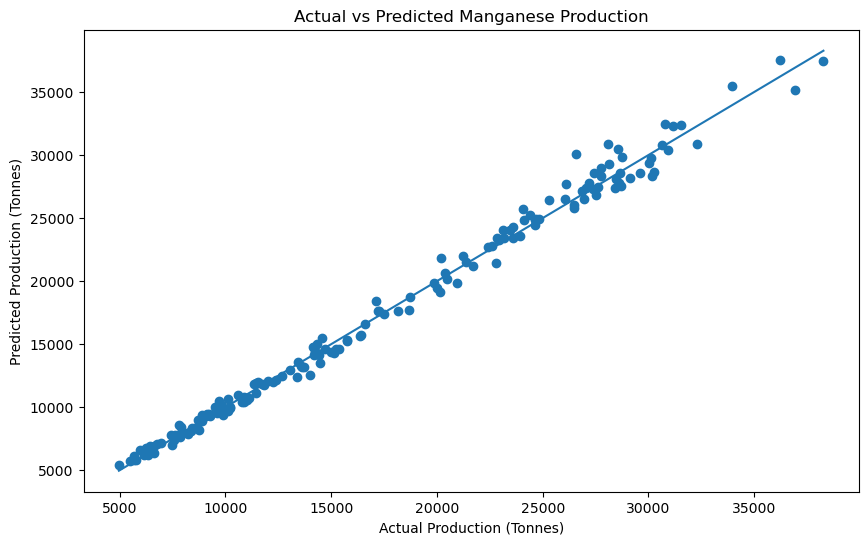

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    prediction_results["Actual Production (Tonnes)"],
    prediction_results["Predicted Production (Tonnes)"]
)

# Perfect prediction line
min_value = min(
    prediction_results["Actual Production (Tonnes)"].min(),
    prediction_results["Predicted Production (Tonnes)"].min()
)

max_value = max(
    prediction_results["Actual Production (Tonnes)"].max(),
    prediction_results["Predicted Production (Tonnes)"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual Production (Tonnes)")
plt.ylabel("Predicted Production (Tonnes)")
plt.title("Actual vs Predicted Manganese Production")

plt.show()

MODEL 1 — EXPLORATION INTELLIGENCE
STEP 1 — Prepare Historical Occurrences


In [11]:
# ============================================================
# MODEL 1 — STEP 1
# PREPARE HISTORICAL MANGANESE OCCURRENCES
# ============================================================

import pandas as pd
import re

# ------------------------------------------------------------
# Load occurrence dataset
# ------------------------------------------------------------

occurrence_file = "manganese_occurrences_SIH26009.csv"

occ = pd.read_csv(occurrence_file)

print("Rows:", len(occ))
print("Columns:", len(occ.columns))

print("\nColumns:")
print(occ.columns.tolist())

display(occ.head())

Rows: 25
Columns: 15

Columns:
['Occurrence_ID', 'Occurrence_Name', 'Mineral', 'Latitude', 'Longitude', 'District', 'State', 'Location_Description', 'Deposit_Type', 'Geological_Formation', 'Host_Rock', 'Historical_Status', 'Source_Name', 'Source_Page', 'Source_Reference']


,Occurrence_ID,Occurrence_Name,Mineral,Latitude,Longitude,District,State,Location_Description,Deposit_Type,Geological_Formation,Host_Rock,Historical_Status,Source_Name,Source_Page,Source_Reference
0,OCC_0001,Balaghat Mine (Bharweli),Manganese,"21°50'00""N","80°14'00""E",Balaghat,Madhya Pradesh,"Bharweli, Manjhara, Manegaon village, Balaghat...",Stratiform metasedimentary bedded oxide,"Mansar Formation, Sausar Group",Phyllite and Sericite Schist,Producing Mine,GSI Bulletin Series A - Economic Geology & MoE...,1-45,MoEF Mining Letter / GSI Memoir on Balaghat Ma...
1,OCC_0002,Ukwa Mine,Manganese,"21°58'00""N","80°28'00""E",Balaghat,Madhya Pradesh,"Ukwa, Baihar / Balaghat Tahsil, Survey of Indi...",Stratiform oxide sheet,"Mansar Formation, Sausar Group","Phyllite, Mica Schist and Quartzite",Producing Mine,MoEF Form-A Subsidence Report Ukwa / GSI CR-01...,1-30,Geological Survey of India Eastern Sausar Belt...
2,OCC_0003,Tirodi Deposit (South Tirodi),Manganese,"21°40'48""N","79°42'00""E",Balaghat,Madhya Pradesh,"Tirodi town / Katangi Tahsil, Toposheet 55O/10",Stratiform gonditic oxide,"Mansar / Lohangi Formation, Sausar Group","Tirodi Biotite Gneiss, Quartz-Muscovite Schist",Producing Mine,GSI Memoir Vol 22 Pt 7 - Geology of Tirodi Man...,1-192,GSI Publication Series - N. A. Vemban and R. A...
3,OCC_0004,Ramrama - Sonawani Area,Manganese,"21°51'32""N","79°56'10""E",Balaghat,Madhya Pradesh,"Ramrama Village, Waraseoni Tahsil, Toposheet 5...",Stratiform metasedimentary,"Mansar Formation / Chorbaoli Contact, Sausar G...",Quartz-Mica Schist and Lohangi Marble,Producing Mine,GSI Bulletin - Geology and Manganese Deposits ...,1-50,GSI Publication Series Part VI - M. R. Subrama...
4,OCC_0005,Sitapatore - Sukli Deposit,Manganese,"21°43'15""N","79°44'30""E",Balaghat,Madhya Pradesh,"Sitapathore and Sukli villages, Waraseoni / Ka...",Stratiform gondite band,"Mansar Formation, Sausar Group",Biotite Gneiss and Gondite,Known Occurrence,GSI Records & MOIL Annual Mineral Report,45-62,IBM Indian Minerals Yearbook Manganese Chapter


In [12]:
# ============================================================
# CONVERT DMS → DECIMAL DEGREES
# ============================================================

def dms_to_decimal(value):
    """
    Convert coordinates such as:
    21°50'00"N
    80°14'00"E

    into decimal degrees.
    """

    if pd.isna(value):
        return None

    value = str(value).strip()

    # Extract degrees, minutes, seconds and direction
    pattern = r"(\d+(?:\.\d+)?)°\s*(\d+(?:\.\d+)?)['′]\s*(\d+(?:\.\d+)?)?[\"″]?\s*([NSEW])"

    match = re.search(pattern, value, re.IGNORECASE)

    if not match:
        return None

    degrees = float(match.group(1))
    minutes = float(match.group(2))
    seconds = float(match.group(3) or 0)
    direction = match.group(4).upper()

    decimal = (
        degrees
        + minutes / 60
        + seconds / 3600
    )

    if direction in ["S", "W"]:
        decimal = -decimal

    return decimal


# ------------------------------------------------------------
# Find coordinate columns
# ------------------------------------------------------------

print("\nCoordinate-related columns:")

for col in occ.columns:
    if "latitude" in col.lower() or "longitude" in col.lower():
        print("-", col)


Coordinate-related columns:
- Latitude
- Longitude


In [14]:
# ============================================================
# MODEL 1 — STEP 1A
# CONVERT DMS COORDINATES TO DECIMAL DEGREES
# ============================================================

import re

def dms_to_decimal(value):
    """
    Convert DMS coordinates such as:
    21°50'00"N
    80°14'00"E

    to decimal degrees.
    """

    if pd.isna(value):
        return None

    value = str(value).strip()

    pattern = r"(\d+(?:\.\d+)?)°\s*(\d+(?:\.\d+)?)['′]\s*(\d+(?:\.\d+)?)?[\"″]?\s*([NSEW])"

    match = re.search(
        pattern,
        value,
        re.IGNORECASE
    )

    if not match:
        return None

    degrees = float(match.group(1))
    minutes = float(match.group(2))
    seconds = float(match.group(3) or 0)

    direction = match.group(4).upper()

    decimal = (
        degrees
        + minutes / 60
        + seconds / 3600
    )

    if direction in ["S", "W"]:
        decimal = -decimal

    return decimal


# Convert coordinates
occ["Latitude_Decimal"] = (
    occ["Latitude"]
    .apply(dms_to_decimal)
)

occ["Longitude_Decimal"] = (
    occ["Longitude"]
    .apply(dms_to_decimal)
)


# ------------------------------------------------------------
# Check conversion
# ------------------------------------------------------------

print("Coordinate conversion results:\n")

display(
    occ[
        [
            "Occurrence_ID",
            "Occurrence_Name",
            "Latitude",
            "Longitude",
            "Latitude_Decimal",
            "Longitude_Decimal"
        ]
    ].head(10)
)

print("\nMissing converted latitudes:",
      occ["Latitude_Decimal"].isna().sum())

print("Missing converted longitudes:",
      occ["Longitude_Decimal"].isna().sum())

Coordinate conversion results:



,Occurrence_ID,Occurrence_Name,Latitude,Longitude,Latitude_Decimal,Longitude_Decimal
0,OCC_0001,Balaghat Mine (Bharweli),"21°50'00""N","80°14'00""E",21.833333,80.233333
1,OCC_0002,Ukwa Mine,"21°58'00""N","80°28'00""E",21.966667,80.466667
2,OCC_0003,Tirodi Deposit (South Tirodi),"21°40'48""N","79°42'00""E",21.680000,79.700000
3,OCC_0004,Ramrama - Sonawani Area,"21°51'32""N","79°56'10""E",21.858889,79.936111
4,OCC_0005,Sitapatore - Sukli Deposit,"21°43'15""N","79°44'30""E",21.720833,79.741667
5,OCC_0006,Miragpur Deposit,"21°37'46""N","79°46'16""E",21.629444,79.771111
6,OCC_0007,Netra Manganese Project,"21°51'52""N","79°58'51""E",21.864444,79.980833
7,OCC_0008,Katangjhari Deposit,"21°49'45""N","79°58'15""E",21.829167,79.970833
8,OCC_0009,Dongri Buzurg Deposit,"21°32'55""N","79°40'58""E",21.548611,79.682778
9,OCC_0010,Chikla - Sitasaongi Deposit,"21°32'13""N","79°44'54""E",21.536944,79.748333



Missing converted latitudes: 0
Missing converted longitudes: 0


In [15]:
study_districts = [
    "Balaghat",
    "Bhandara",
    "Nagpur"
]

study_occ = occ[
    occ["District"]
    .str.strip()
    .str.lower()
    .isin([x.lower() for x in study_districts])
].copy()

print("=" * 70)
print("MOIL STUDY AREA OCCURRENCES")
print("=" * 70)

print("\nTotal occurrences:", len(occ))
print("Occurrences inside study area:", len(study_occ))
print("Occurrences outside study area:", len(occ) - len(study_occ))

print("\nOccurrences by district:")
print(study_occ["District"].value_counts())

print("\nOccurrences:")

display(
    study_occ[
        [
            "Occurrence_ID",
            "Occurrence_Name",
            "District",
            "State",
            "Latitude_Decimal",
            "Longitude_Decimal",
            "Historical_Status"
        ]
    ].sort_values(
        ["District", "Occurrence_Name"]
    )
)

MOIL STUDY AREA OCCURRENCES

Total occurrences: 25
Occurrences inside study area: 18
Occurrences outside study area: 7

Occurrences by district:
District
Balaghat    8
Nagpur      7
Bhandara    3
Name: count, dtype: int64

Occurrences:


,Occurrence_ID,Occurrence_Name,District,State,Latitude_Decimal,Longitude_Decimal,Historical_Status
0,OCC_0001,Balaghat Mine (Bharweli),Balaghat,Madhya Pradesh,21.833333,80.233333,Producing Mine
7,OCC_0008,Katangjhari Deposit,Balaghat,Madhya Pradesh,21.829167,79.970833,Deposit
5,OCC_0006,Miragpur Deposit,Balaghat,Madhya Pradesh,21.629444,79.771111,Known Occurrence
6,OCC_0007,Netra Manganese Project,Balaghat,Madhya Pradesh,21.864444,79.980833,Prospect
3,OCC_0004,Ramrama - Sonawani Area,Balaghat,Madhya Pradesh,21.858889,79.936111,Producing Mine
4,OCC_0005,Sitapatore - Sukli Deposit,Balaghat,Madhya Pradesh,21.720833,79.741667,Known Occurrence
2,OCC_0003,Tirodi Deposit (South Tirodi),Balaghat,Madhya Pradesh,21.680000,79.700000,Producing Mine
1,OCC_0002,Ukwa Mine,Balaghat,Madhya Pradesh,21.966667,80.466667,Producing Mine
9,OCC_0010,Chikla - Sitasaongi Deposit,Bhandara,Maharashtra,21.536944,79.748333,Producing Mine
8,OCC_0009,Dongri Buzurg Deposit,Bhandara,Maharashtra,21.548611,79.682778,Producing Mine


In [16]:
# ============================================================
# MODEL 1 — STEP 1C
# SAVE CLEAN MOIL OCCURRENCE DATA
# ============================================================

output_file = "manganese_occurrences_MOIL_study_area.csv"

study_occ.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("✓ Clean occurrence dataset saved:")
print(output_file)

print("\nRows:", len(study_occ))
print("Columns:", len(study_occ.columns))

✓ Clean occurrence dataset saved:
manganese_occurrences_MOIL_study_area.csv

Rows: 18
Columns: 17
